In [2]:
from google.colab import files
uploaded = files.upload()

Saving car_prediction_data.csv to car_prediction_data.csv


In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [4]:
df = pd.read_csv('car_prediction_data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [6]:
print(df.shape)

(301, 9)


In [9]:
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())
print(df['Owner'].unique())
print(df['Fuel_Type'].unique())
print(df['Car_Name'].unique())

['Dealer' 'Individual']
['Manual' 'Automatic']
[0 1 3]
['Petrol' 'Diesel' 'CNG']
['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Act

In [10]:
l = LabelEncoder()
df['Seller_Type'] = l.fit_transform(df['Seller_Type'])
df['Transmission'] = l.fit_transform(df['Transmission'])
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,0,1,0
1,sx4,2013,4.75,9.54,43000,Diesel,0,1,0
2,ciaz,2017,7.25,9.85,6900,Petrol,0,1,0
3,wagon r,2011,2.85,4.15,5200,Petrol,0,1,0
4,swift,2014,4.60,6.87,42450,Diesel,0,1,0


In [14]:
categorical_cols = ['Fuel_Type','Car_Name']
numerical_cols = ['Year','Present_Price','Kms_Driven','Owner','Seller_Type','Transmission']
preprocessor = ColumnTransformer(
    transformers = [
        ('num',StandardScaler(),numerical_cols),
        ('cat',OneHotEncoder(handle_unknown = 'ignore'),categorical_cols)
    ],
    remainder = 'passthrough'
)

In [15]:
x = df.drop('Selling_Price',axis = 1)
y = df['Selling_Price']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [16]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [18]:
rf_model = RandomForestRegressor(n_estimators = 200,random_state = 42)
rf_model.fit(x_train,y_train)
rf_pred = rf_model.predict(x_test)
mae_rf = mean_absolute_error(y_test,rf_pred)
mse_rf = mean_squared_error(y_test,rf_pred)
rmse_rf = np.sqrt(mse_rf)
r2_score_rf = r2_score(y_test,rf_pred)
print("MAE:",mae_rf)
print("MSE:",mse_rf)
print("RMSE:",rmse_rf)
print("R2 Score:",r2_score_rf)

MAE: 0.5972081967213108
MSE: 0.8103546461475395
RMSE: 0.9001970040760742
R2 Score: 0.9648216156427999


In [19]:
gbr = GradientBoostingRegressor(n_estimators = 200,learning_rate= 0.05,random_state = 42,max_depth = 3)
gbr.fit(x_train,y_train)
gbr_pred = gbr.predict(x_test)
mae_gbr = mean_absolute_error(y_test,gbr_pred)
mse_gbr = mean_squared_error(y_test,gbr_pred)
rmse_gbr = np.sqrt(mse_gbr)
r2_score_gbr = r2_score(y_test,gbr_pred)
print("MAE:",mae_gbr)
print("MSE:",mse_gbr)
print("RMSE:",rmse_gbr)
print("R2 Score:",r2_score_gbr)

MAE: 0.5823746546994214
MSE: 0.9176017922833448
RMSE: 0.9579153366990972
R2 Score: 0.9601658993512797


In [20]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)
xgb_model.fit(x_train,y_train)
xgb_pred = xgb_model.predict(x_test)
mae_xgb = mean_absolute_error(y_test,xgb_pred)
mse_xgb = mean_squared_error(y_test,xgb_pred)
rmse_xgb = np.sqrt(mse_xgb)
r2_score_xgb = r2_score(y_test,xgb_pred)
print("MAE:",mae_xgb)
print("MSE:",mse_xgb)
print("RMSE:",rmse_xgb)
print("R2 Score:",r2_score_xgb)

MAE: 0.5468726704355146
MSE: 0.6799386019818228
RMSE: 0.8245838962663671
R2 Score: 0.970483119220052


In [23]:
print("Model Comparison")
print("=" * 65)

print(f"{'Model':<25} {'MAE':<10} {'RMSE':<10} {'R²':<10}")
print("-" * 65)
print(f"{'Random Forest':<25} {mae_rf:<10.4f} {rmse_rf:<10.4f} {r2_score_rf:<10.4f}")
print(f"{'Gradient Boosting':<25} {mae_gbr:<10.4f} {rmse_gbr:<10.4f} {r2_score_gbr:<10.4f}")
print(f"{'XGBoost':<25} {mae_xgb:<10.4f} {rmse_xgb:<10.4f} {r2_score_xgb:<10.4f}")

Model Comparison
Model                     MAE        RMSE       R²        
-----------------------------------------------------------------
Random Forest             0.5972     0.9002     0.9648    
Gradient Boosting         0.5824     0.9579     0.9602    
XGBoost                   0.5469     0.8246     0.9705    


In [25]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [1, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring="r2",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV R²:")
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

Best CV R²:
0.8989002329516207


In [27]:
xgb_tuned = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.1,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=10,
    random_state = 42
)
xgb_tuned.fit(x_train,y_train)
xgb_tuned_pred = xgb_tuned.predict(x_test)
mae_xgb_tuned = mean_absolute_error(y_test,xgb_tuned_pred)
mse_xgb_tuned = mean_squared_error(y_test,xgb_tuned_pred)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_score_xgb_tuned = r2_score(y_test,xgb_tuned_pred)
print("MAE:",mae_xgb_tuned)
print("MSE:",mse_xgb_tuned)
print("RMSE:",rmse_xgb_tuned)
print("R2 Score:",r2_score_xgb_tuned)

MAE: 0.6047316703249196
MSE: 1.1984031231879253
RMSE: 1.0947160011564303
R2 Score: 0.9479760054652685


In [28]:
xgb_model.score(x_test,y_test)

0.970483119220052

In [29]:
xgb_model.score(x_train,y_train)

0.9943251998619073

In [31]:
xgb_tuned.score(x_test,y_test)

0.9479760054652685

In [32]:
xgb_tuned.score(x_train,y_train)

0.9989176896522857

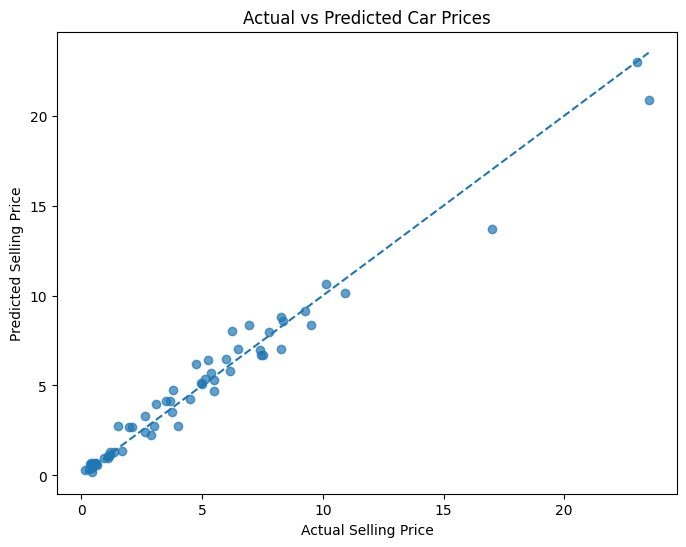

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, xgb_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()